# Desafio Integrador – Pré-processamento de Dados para Machine Learning

**Curso:** Machine Learning Aplicada à Indústria  
**Desafio complementar às Aulas 1, 2 e 3**

## Objetivo
Aplicar os conceitos de:
- entendimento do problema;
- inspeção inicial da base;
- tratamento de faltantes;
- remoção de duplicatas;
- tratamento de outliers;
- normalização/padronização;
- codificação de variáveis categóricas;
- preparação final da base para modelagem.

## Entregáveis
1. Base diagnosticada.
2. Base tratada.
3. Base final pronta para ML.
4. Resumo técnico das decisões adotadas.

In [147]:
# Instale as bibliotecas se necessário
# !pip install pandas numpy matplotlib seaborn scikit-learn kagglehub -q

In [148]:
#importar pandas as pd
#importar numpy as np
#importar matplotlib.pyplot as plt
#importar sklearn.preprocessing de MinMaxScaler, StandardScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler


pd.set_option('display.max_columns', None)

## 1. Carregamento da base

Você pode usar:
- a base das aulas anteriores; ou
- uma base do Kaggle baixada manualmente.

Substitua o caminho abaixo, se necessário.

In [149]:
CAMINHO_ARQUIVO = '/content/dados_desafio_preprocessamento_industria_v2.csv'
df = pd.read_csv(CAMINHO_ARQUIVO)
df.head()

,timestamp,linha_producao,turno,produto_quimico,tipo_valvula,status_sensor,vazao_setpoint_l_min,pressao_linha_bar,temperatura_produto_c,abertura_valvula_pct,vibracao_bomba_mm_s,ph_produto,consumo_energia_kwh,tempo_resposta_seg,erro_vazao_pct,leituras_invalidas,horas_operacao_bomba,status_instrumentacao
0,2026-03-06 07:00:00,Linha_C,Manhã,Ácido_Y,Borboleta,OK,127.66,4.46,45.51,80.42,3.53,7.58,18.01,3.29,4.66,3,3133,Normal
1,2026-03-02 17:00:00,Linha_B,Noite,Base_Z,Esfera,OK,131.68,5.09,35.64,61.61,1.61,8.19,25.60,1.62,5.64,1,1547,Normal
2,2026-03-03 07:00:00,Linha_C,Tarde,Ácido_Y,Globo,Instável,158.94,5.06,36.43,45.48,4.01,8.02,30.05,1.45,5.06,2,2300,Alerta
3,2026-03-07 14:00:00,Linha_A,Noite,Solvente_X,Globo,OK,157.35,4.73,39.69,47.95,2.41,6.85,14.89,2.74,3.06,1,3694,Normal
4,2026-03-10 02:00:00,Linha_B,Noite,Base_Z,Esfera,OK,121.38,4.80,32.98,54.65,1.98,6.38,15.02,1.70,7.41,1,2337,Normal


## 2. Compreensão inicial da base

**Tarefa:**  
Analise a estrutura da base e descreva:
- quantidade de linhas e colunas;
- tipos de dados;
- variável-alvo provável;
- possíveis problemas de qualidade dos dados.

###Exibição estatistica do dataset

In [150]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,235,220,2026-03-05 19:00:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
linha_producao,235,6,Linha_A,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
turno,235,3,Noite,79,NaN,NaN,NaN,NaN,NaN,NaN,NaN
produto_quimico,235,4,Solvente_X,79,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_valvula,225,6,Globo,109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status_sensor,227,6,OK,172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vazao_setpoint_l_min,235.0,NaN,NaN,NaN,122.31217,17.305861,70.0,110.405,123.49,132.66,165.48
pressao_linha_bar,221.0,NaN,NaN,NaN,4.905204,1.069796,0.6,4.25,4.88,5.47,12.4
temperatura_produto_c,222.0,NaN,NaN,NaN,39.190225,10.018162,-8.0,33.76,38.4,43.12,105.3
abertura_valvula_pct,223.0,NaN,NaN,NaN,56.167848,17.225327,5.0,46.055,54.65,68.015,100.0


In [151]:
# Complete a análise inicial
print("Dimensões:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)

Dimensões: (235, 18)

Tipos de dados:
timestamp                 object
linha_producao            object
turno                     object
produto_quimico           object
tipo_valvula              object
status_sensor             object
vazao_setpoint_l_min     float64
pressao_linha_bar        float64
temperatura_produto_c    float64
abertura_valvula_pct     float64
vibracao_bomba_mm_s      float64
ph_produto               float64
consumo_energia_kwh      float64
tempo_resposta_seg       float64
erro_vazao_pct           float64
leituras_invalidas         int64
horas_operacao_bomba       int64
status_instrumentacao     object
dtype: object


In [152]:
# Exiba estatísticas descritivas
df.describe()

,vazao_setpoint_l_min,pressao_linha_bar,temperatura_produto_c,abertura_valvula_pct,vibracao_bomba_mm_s,ph_produto,consumo_energia_kwh,tempo_resposta_seg,erro_vazao_pct,leituras_invalidas,horas_operacao_bomba
count,235.000000,221.000000,222.000000,223.000000,235.000000,226.000000,224.000000,235.00000,229.000000,235.000000,235.000000
mean,122.312170,4.905204,39.190225,56.167848,2.878255,6.706416,24.385179,1.80800,3.695328,1.446809,2340.536170
std,17.305861,1.069796,10.018162,17.225327,1.409656,1.231081,7.308058,0.49963,2.262931,1.173214,730.111139
min,70.000000,0.600000,-8.000000,5.000000,0.370000,2.870000,4.100000,0.48000,0.000000,0.000000,249.000000
25%,110.405000,4.250000,33.760000,46.055000,2.170000,5.920000,20.100000,1.45000,1.910000,1.000000,1802.500000
50%,123.490000,4.880000,38.400000,54.650000,2.770000,6.785000,24.065000,1.79000,3.560000,1.000000,2337.000000
75%,132.660000,5.470000,43.120000,68.015000,3.420000,7.580000,28.085000,2.13500,5.200000,2.000000,2790.500000
max,165.480000,12.400000,105.300000,100.000000,14.700000,10.390000,72.400000,3.29000,10.230000,6.000000,3924.000000


In [153]:
# Defina a variável-alvo, se houver
target = 'status_instrumentacao'


## 3. Diagnóstico da qualidade dos dados

**Tarefa:**  
Verifique:
- valores faltantes;
- duplicatas;
- colunas numéricas;
- colunas categóricas.

In [154]:
# Conte os valores faltantes por coluna
df.isna().sum().sort_values(ascending=False)

,0
pressao_linha_bar,14
temperatura_produto_c,13
abertura_valvula_pct,12
consumo_energia_kwh,11
tipo_valvula,10
ph_produto,9
status_sensor,8
erro_vazao_pct,6
linha_producao,0
timestamp,0


In [155]:
# Conte as linhas duplicadas
df.duplicated().sum()

np.int64(15)

In [156]:
# Separe colunas numéricas e categóricas
colunas_numericas = df.select_dtypes(include='number').columns.tolist()
colunas_categoricas =df.select_dtypes(include='object').columns.tolist()

print("Numéricas:", colunas_numericas)
print("Categóricas:", colunas_categoricas)

Numéricas: ['vazao_setpoint_l_min', 'pressao_linha_bar', 'temperatura_produto_c', 'abertura_valvula_pct', 'vibracao_bomba_mm_s', 'ph_produto', 'consumo_energia_kwh', 'tempo_resposta_seg', 'erro_vazao_pct', 'leituras_invalidas', 'horas_operacao_bomba']
Categóricas: ['timestamp', 'linha_producao', 'turno', 'produto_quimico', 'tipo_valvula', 'status_sensor', 'status_instrumentacao']


## 4. Tratamento de duplicatas

**Tarefa:**  
Crie uma cópia da base e remova as linhas duplicadas.

In [157]:
df_tratado =df.copy()

antes = df_tratado.shape[0]
df_tratado = df_tratado.drop_duplicates()
depois = df_tratado.shape[0]

print("Linhas antes:", antes)
print("Linhas depois:", depois)
print("Duplicatas removidas:", int(antes-depois))

Linhas antes: 235
Linhas depois: 220
Duplicatas removidas: 15


## 5. Tratamento de valores faltantes

**Tarefa:**  
- Use **mediana** nas colunas numéricas;
- Use **moda** nas colunas categóricas.

In [158]:
# Preencha valores faltantes das colunas numéricas
for col in colunas_numericas:
    df_tratado[col] = df_tratado[col].fillna(df_tratado[col].median())

# Preencha valores faltantes das colunas categóricas
for col in colunas_categoricas:
    moda = df_tratado[col].mode()[0]
    df_tratado[col] = df_tratado[col].fillna(moda)

print(df_tratado.isna().sum().sort_values(ascending=False))

timestamp                0
linha_producao           0
turno                    0
produto_quimico          0
tipo_valvula             0
status_sensor            0
vazao_setpoint_l_min     0
pressao_linha_bar        0
temperatura_produto_c    0
abertura_valvula_pct     0
vibracao_bomba_mm_s      0
ph_produto               0
consumo_energia_kwh      0
tempo_resposta_seg       0
erro_vazao_pct           0
leituras_invalidas       0
horas_operacao_bomba     0
status_instrumentacao    0
dtype: int64


## 6. Tratamento de outliers com IQR

**Tarefa:**  
Implemente a função de tratamento de outliers por IQR e aplique na base.

In [159]:
def tratar_outliers_iqr(df_entrada, colunas):
    df_saida = df_entrada.copy()
    relatorio = []

    for col in colunas:
        q1 = df_saida[col].quantile(0.25)
        q3 = df_saida[col].quantile(0.75)
        iqr = q3-q1
        lim_inf = q1-(1.5*iqr)
        lim_sup = q3+(1.5*iqr)

        qtd_antes = ((df_saida[col] < lim_inf) | (df_saida[col] > lim_sup)).sum()

        df_saida[col] = np.where(df_saida[col] < lim_inf, lim_inf, df_saida[col])
        df_saida[col] = np.where(df_saida[col] > lim_sup, lim_sup, df_saida[col])


        qtd_depois = ((df_saida[col] < lim_inf) | (df_saida[col] > lim_sup)).sum()

        relatorio.append({
            'coluna': col,
            'limite_inferior': lim_inf,
            'limite_superior': lim_sup,
            'outliers_antes': int(qtd_antes),
            'outliers_depois': int(qtd_depois)
        })

    return df_saida, pd.DataFrame(relatorio)

In [160]:
colunas_numericas_trat =df_tratado.select_dtypes(include=[np.number]).columns.tolist()
df_tratado, relatorio_outliers = tratar_outliers_iqr(df_tratado, colunas_numericas_trat)

relatorio_outliers

,coluna,limite_inferior,limite_superior,outliers_antes,outliers_depois
0,vazao_setpoint_l_min,75.81375,168.10375,1,0
1,pressao_linha_bar,2.68500,6.98500,4,0
2,temperatura_produto_c,20.97375,56.08375,6,0
3,abertura_valvula_pct,16.14875,96.85875,7,0
4,vibracao_bomba_mm_s,0.37000,5.27000,3,0
5,ph_produto,3.64125,9.93125,6,0
6,consumo_energia_kwh,8.26500,39.84500,4,0
7,tempo_resposta_seg,0.41500,3.17500,2,0
8,erro_vazao_pct,-2.31875,9.53125,1,0
9,leituras_invalidas,-0.50000,3.50000,12,0


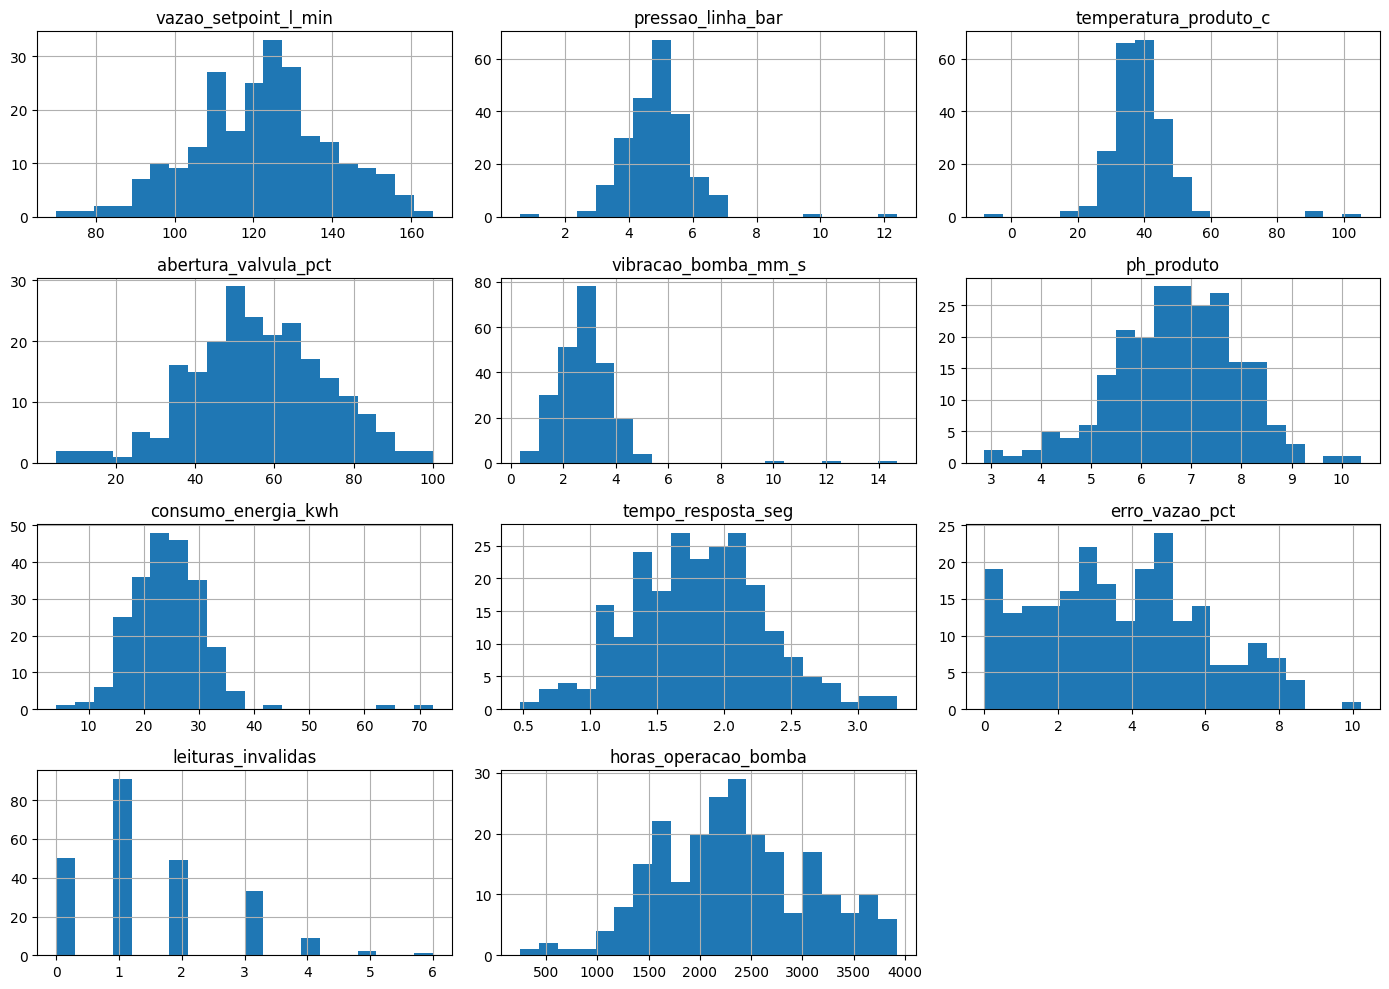

In [161]:
# Visualização rápida da distribuição das variáveis numéricas
if colunas_numericas_trat:
    df[colunas_numericas_trat].hist(figsize=(14, 10), bins=20)
    plt.tight_layout()
    plt.show()

## 7. Codificação de variáveis categóricas

**Tarefa:**  
Separe `X` e `y` e aplique `get_dummies()` nas variáveis preditoras.

In [162]:
# Se existir target categórico, vamos preservá-lo antes da codificação geral
if target and target in df_tratado.columns:
    X = df_tratado.drop(columns=[target])
    y = df_tratado[target].copy()
else:
    X = df_tratado.copy()
    y = None

X['timestamp'] = pd.to_datetime(X['timestamp'])

X_codificado = pd.get_dummies(X, drop_first=False)
print('Dimensão antes da codificação:', X.shape)
print('Dimensão depois da codificação:', X_codificado.shape)
X_codificado.head()

Dimensão antes da codificação: (220, 17)
Dimensão depois da codificação: (220, 37)


,timestamp,vazao_setpoint_l_min,pressao_linha_bar,temperatura_produto_c,abertura_valvula_pct,vibracao_bomba_mm_s,ph_produto,consumo_energia_kwh,tempo_resposta_seg,erro_vazao_pct,leituras_invalidas,horas_operacao_bomba,linha_producao_LINHA_B,linha_producao_Linha c,linha_producao_Linha_A,linha_producao_Linha_B,linha_producao_Linha_C,linha_producao_linha_a,turno_Manhã,turno_Noite,turno_Tarde,produto_quimico_Aditivo_W,produto_quimico_Base_Z,produto_quimico_Solvente_X,produto_quimico_Ácido_Y,tipo_valvula_ ESFERA,tipo_valvula_Borboleta,tipo_valvula_Esfera,tipo_valvula_Globo,tipo_valvula_borboleta,tipo_valvula_globo,status_sensor_INSTAVEL,status_sensor_Instável,status_sensor_Manutenção,status_sensor_OK,status_sensor_manutencao,status_sensor_ok
0,2026-03-06 07:00:00,127.66,4.46,45.51,80.42,3.53,7.58,18.01,3.175,4.66,3.0,3133.0,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False
1,2026-03-02 17:00:00,131.68,5.09,35.64,61.61,1.61,8.19,25.60,1.620,5.64,1.0,1547.0,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False
2,2026-03-03 07:00:00,158.94,5.06,36.43,45.48,4.01,8.02,30.05,1.450,5.06,2.0,2300.0,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False
3,2026-03-07 14:00:00,157.35,4.73,39.69,47.95,2.41,6.85,14.89,2.740,3.06,1.0,3694.0,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False
4,2026-03-10 02:00:00,121.38,4.80,32.98,54.65,1.98,6.38,15.02,1.700,7.41,1.0,2337.0,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False


## 8. Normalização e padronização

**Tarefa:**  
Crie:
- uma versão normalizada da base;
- uma versão padronizada da base.

In [163]:
colunas_numericas_final = X_codificado.select_dtypes(include=[np.number]).columns.tolist()

# Base normalizada
scaler_minmax = MinMaxScaler()
X_normalizado = X_codificado.copy()
X_normalizado[colunas_numericas_final] = scaler_minmax.fit_transform(X_normalizado[colunas_numericas_final])

# Base padronizada
scaler_standard = StandardScaler()
X_padronizado = X_codificado.copy()
X_padronizado[colunas_numericas_final] = scaler_standard.fit_transform(X_padronizado[colunas_numericas_final])

print('Base normalizada:')
display(X_normalizado.head())

print('Base padronizada:')
display(X_padronizado.head())

Base normalizada:


,timestamp,vazao_setpoint_l_min,pressao_linha_bar,temperatura_produto_c,abertura_valvula_pct,vibracao_bomba_mm_s,ph_produto,consumo_energia_kwh,tempo_resposta_seg,erro_vazao_pct,leituras_invalidas,horas_operacao_bomba,linha_producao_LINHA_B,linha_producao_Linha c,linha_producao_Linha_A,linha_producao_Linha_B,linha_producao_Linha_C,linha_producao_linha_a,turno_Manhã,turno_Noite,turno_Tarde,produto_quimico_Aditivo_W,produto_quimico_Base_Z,produto_quimico_Solvente_X,produto_quimico_Ácido_Y,tipo_valvula_ ESFERA,tipo_valvula_Borboleta,tipo_valvula_Esfera,tipo_valvula_Globo,tipo_valvula_borboleta,tipo_valvula_globo,status_sensor_INSTAVEL,status_sensor_Instável,status_sensor_Manutenção,status_sensor_OK,status_sensor_manutencao,status_sensor_ok
0,2026-03-06 07:00:00,0.578214,0.412791,0.698839,0.796323,0.644898,0.626192,0.308581,1.000000,0.488918,0.857143,0.780947,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False
1,2026-03-02 17:00:00,0.623047,0.559302,0.417723,0.563267,0.253061,0.723172,0.548923,0.423006,0.591738,0.285714,0.341734,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False
2,2026-03-03 07:00:00,0.927063,0.552326,0.440224,0.363415,0.742857,0.696145,0.689835,0.359926,0.530885,0.571429,0.550263,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False
3,2026-03-07 14:00:00,0.909330,0.475581,0.533075,0.394019,0.416327,0.510135,0.209785,0.838590,0.321049,0.285714,0.936306,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False
4,2026-03-10 02:00:00,0.508176,0.491860,0.341961,0.477032,0.328571,0.435413,0.213901,0.452690,0.777443,0.285714,0.560510,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False


Base padronizada:


,timestamp,vazao_setpoint_l_min,pressao_linha_bar,temperatura_produto_c,abertura_valvula_pct,vibracao_bomba_mm_s,ph_produto,consumo_energia_kwh,tempo_resposta_seg,erro_vazao_pct,leituras_invalidas,horas_operacao_bomba,linha_producao_LINHA_B,linha_producao_Linha c,linha_producao_Linha_A,linha_producao_Linha_B,linha_producao_Linha_C,linha_producao_linha_a,turno_Manhã,turno_Noite,turno_Tarde,produto_quimico_Aditivo_W,produto_quimico_Base_Z,produto_quimico_Solvente_X,produto_quimico_Ácido_Y,tipo_valvula_ ESFERA,tipo_valvula_Borboleta,tipo_valvula_Esfera,tipo_valvula_Globo,tipo_valvula_borboleta,tipo_valvula_globo,status_sensor_INSTAVEL,status_sensor_Instável,status_sensor_Manutenção,status_sensor_OK,status_sensor_manutencao,status_sensor_ok
0,2026-03-06 07:00:00,0.287625,-0.499516,0.972582,1.480023,0.773732,0.720022,-1.020541,2.746769,0.426902,1.489654,1.086744,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False
1,2026-03-02 17:00:00,0.518403,0.251465,-0.469833,0.334343,-1.278155,1.242153,0.255766,-0.381292,0.870899,-0.372414,-1.090813,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False
2,2026-03-03 07:00:00,2.083326,0.215704,-0.354381,-0.648103,1.286704,1.096641,1.004061,-0.723267,0.608125,0.558620,-0.056954,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False
3,2026-03-07 14:00:00,1.992048,-0.177667,0.122040,-0.497660,-0.423202,0.095176,-1.545188,1.871716,-0.297991,-0.372414,1.856990,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False
4,2026-03-10 02:00:00,-0.072893,-0.094225,-0.858568,-0.089577,-0.882739,-0.307122,-1.523328,-0.220363,1.672812,-0.372414,-0.006153,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False


## 9. Base final pronta para modelagem

**Tarefa:**  
Escolha a base final que será utilizada em um futuro algoritmo de ML e reconecte a variável-alvo, se houver.

In [164]:
# Escolha da base final
base_final_modelagem = X_padronizado.copy()

if y is not None:
    base_final_modelagem[target] = y.values

print('Dimensão final da base pronta para modelagem:', base_final_modelagem.shape)
base_final_modelagem.head()

Dimensão final da base pronta para modelagem: (220, 38)


,timestamp,vazao_setpoint_l_min,pressao_linha_bar,temperatura_produto_c,abertura_valvula_pct,vibracao_bomba_mm_s,ph_produto,consumo_energia_kwh,tempo_resposta_seg,erro_vazao_pct,leituras_invalidas,horas_operacao_bomba,linha_producao_LINHA_B,linha_producao_Linha c,linha_producao_Linha_A,linha_producao_Linha_B,linha_producao_Linha_C,linha_producao_linha_a,turno_Manhã,turno_Noite,turno_Tarde,produto_quimico_Aditivo_W,produto_quimico_Base_Z,produto_quimico_Solvente_X,produto_quimico_Ácido_Y,tipo_valvula_ ESFERA,tipo_valvula_Borboleta,tipo_valvula_Esfera,tipo_valvula_Globo,tipo_valvula_borboleta,tipo_valvula_globo,status_sensor_INSTAVEL,status_sensor_Instável,status_sensor_Manutenção,status_sensor_OK,status_sensor_manutencao,status_sensor_ok,status_instrumentacao
0,2026-03-06 07:00:00,0.287625,-0.499516,0.972582,1.480023,0.773732,0.720022,-1.020541,2.746769,0.426902,1.489654,1.086744,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,Normal
1,2026-03-02 17:00:00,0.518403,0.251465,-0.469833,0.334343,-1.278155,1.242153,0.255766,-0.381292,0.870899,-0.372414,-1.090813,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,Normal
2,2026-03-03 07:00:00,2.083326,0.215704,-0.354381,-0.648103,1.286704,1.096641,1.004061,-0.723267,0.608125,0.558620,-0.056954,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,Alerta
3,2026-03-07 14:00:00,1.992048,-0.177667,0.122040,-0.497660,-0.423202,0.095176,-1.545188,1.871716,-0.297991,-0.372414,1.856990,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,Normal
4,2026-03-10 02:00:00,-0.072893,-0.094225,-0.858568,-0.089577,-0.882739,-0.307122,-1.523328,-0.220363,1.672812,-0.372414,-0.006153,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,Normal


## 10. Resumo técnico

Preencha abaixo um resumo do que foi feito no seu pré-processamento.

In [165]:
# Exemplo de resumo técnico
resumo = {
    'arquivo_utilizado': CAMINHO_ARQUIVO,
    'linhas_iniciais': int(df.shape[0]),
    'colunas_iniciais': int(df.shape[1]),
    'duplicatas_iniciais': int(df.duplicated().sum()),
    'linhas_finais': int(base_final_modelagem.shape[0]),
    'colunas_finais': int(base_final_modelagem.shape[1]),
    'target': target,
    'tratamento_faltantes': 'mediana para numéricas e moda para categóricas',
    'tratamento_outliers': 'capping por IQR',
    'codificacao': 'one-hot encoding com pandas.get_dummies',
    'transformacao_final': 'padronização com StandardScaler'
}

pd.DataFrame([resumo])

,arquivo_utilizado,linhas_iniciais,colunas_iniciais,duplicatas_iniciais,linhas_finais,colunas_finais,target,tratamento_faltantes,tratamento_outliers,codificacao,transformacao_final
0,/content/dados_desafio_preprocessamento_indust...,235,18,15,220,38,status_instrumentacao,mediana para numéricas e moda para categóricas,capping por IQR,one-hot encoding com pandas.get_dummies,padronização com StandardScaler


In [166]:
# Exportação da base final
base_final_modelagem.to_csv('base_final_desafio_preprocessamento.csv', index=False)
print('Arquivo salvo em: base_final_desafio_preprocessamento.csv')

Arquivo salvo em: base_final_desafio_preprocessamento.csv
